Tree nodes: 40


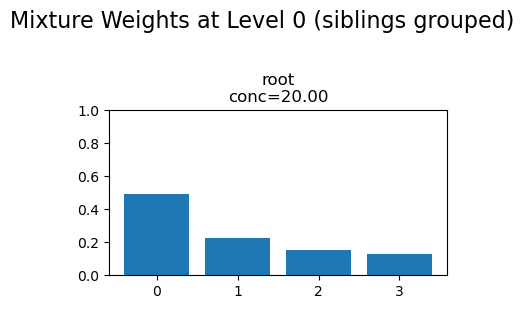

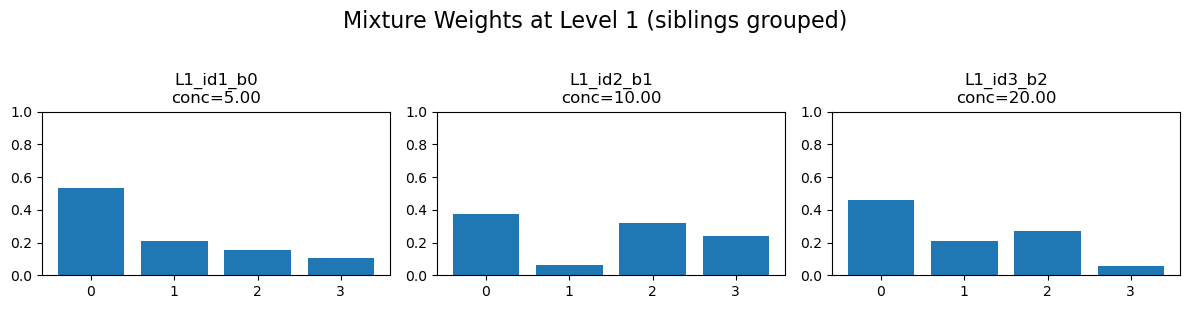

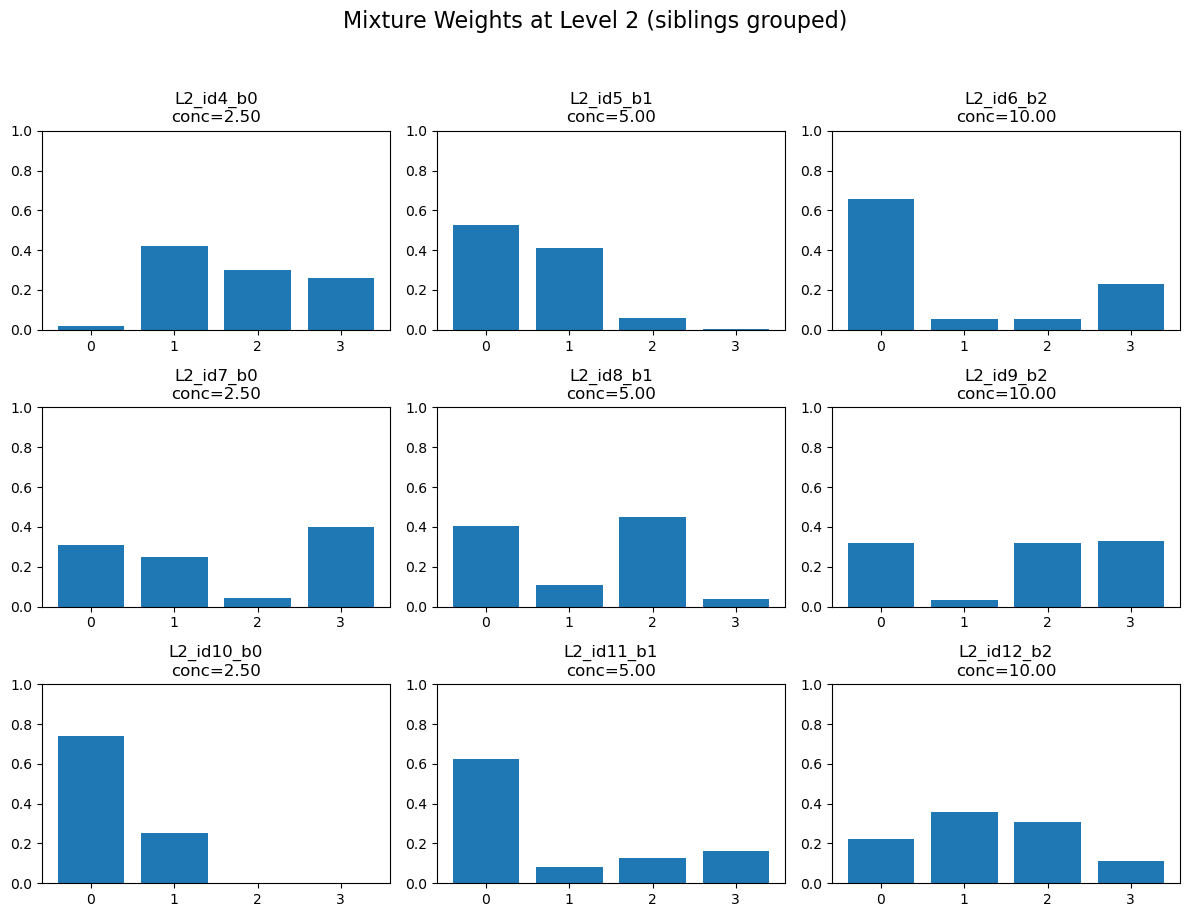

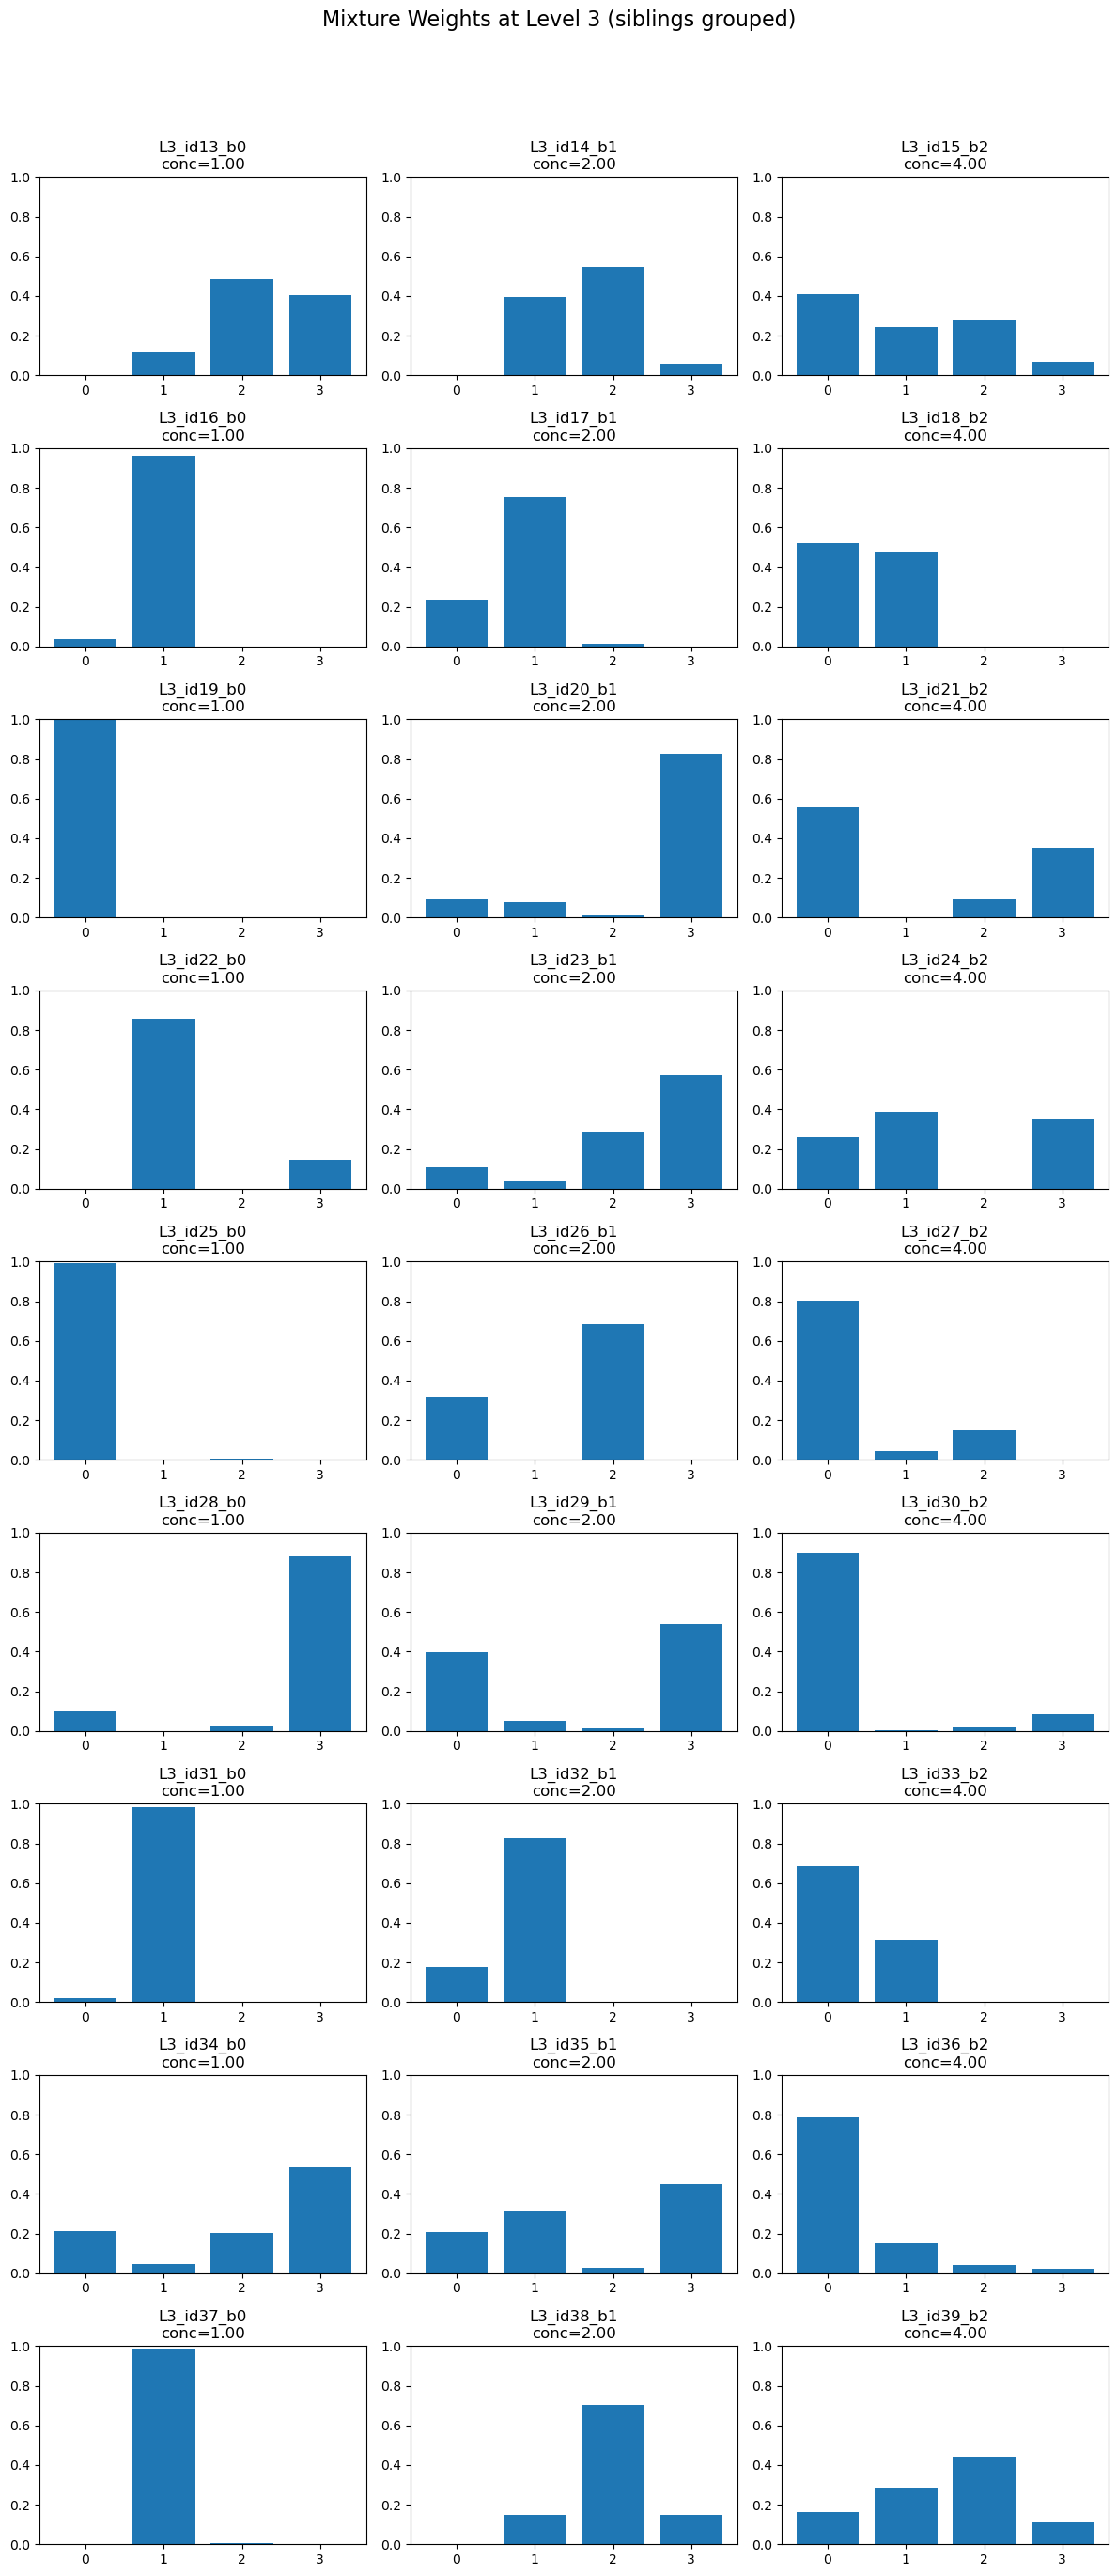

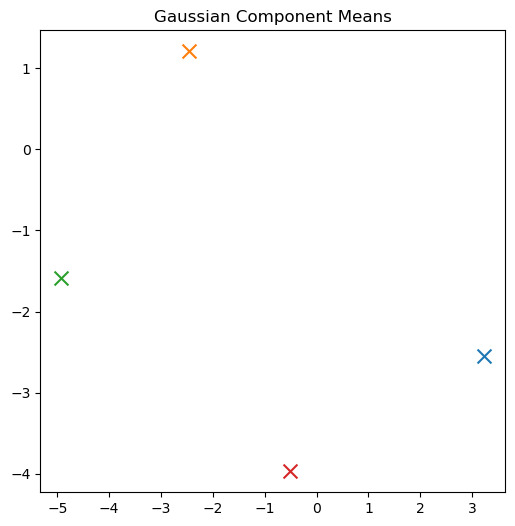

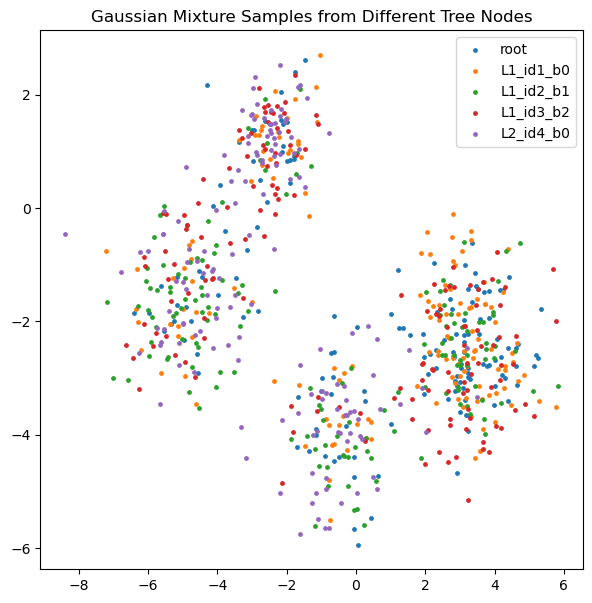

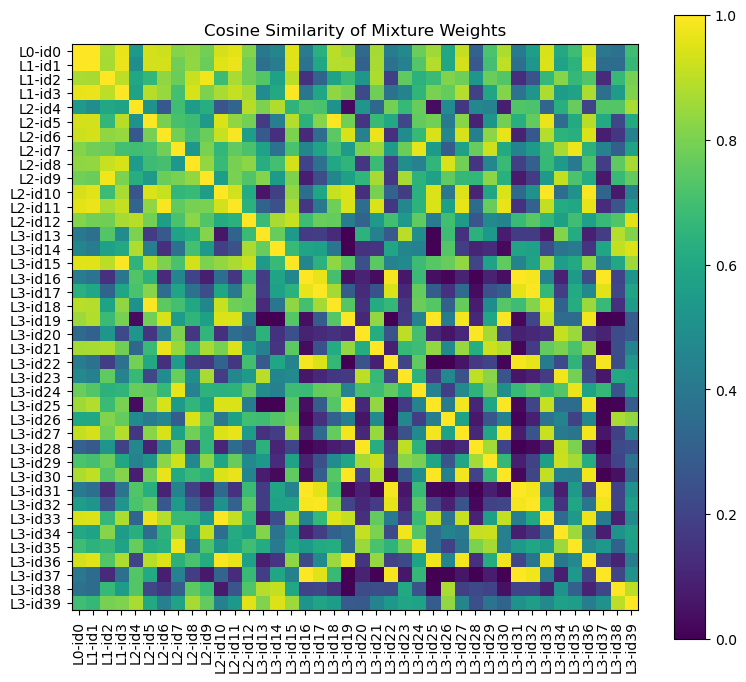

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Optional


# ====================================================
# CONFIG
# ====================================================
torch.manual_seed(0)

K = 4               # number of mixture components
V = 15              # vocab size for multinomial model
DIM = 2             # dimension of Gaussian components

MAX_DEPTH = 3
BRANCHING = 3

DEPTH_CONC = {0: 20.0, 1: 10.0, 2: 5.0, 3: 2.0}
BRANCH_MULT = {0: 0.5, 1: 1.0, 2: 2.0}

SAMPLES_PER_NODE = 150


# ====================================================
# DIRICHLET TREE
# ====================================================
@dataclass
class TreeNode:
    node_id: int
    name: str
    level: int
    parent_id: Optional[int]
    alpha: torch.Tensor
    theta: torch.Tensor
    conc: float


def normalize(v):
    return v / v.sum(dim=-1, keepdim=True)


def build_root(K):
    mean = normalize(torch.ones(K))
    conc = DEPTH_CONC[0]
    alpha = conc * mean
    theta = torch.distributions.Dirichlet(alpha).sample()
    return TreeNode(0, "root", 0, None, alpha, theta, conc)


def build_dirichlet_tree(K, max_depth, branching):
    nodes = [build_root(K)]
    frontier = [nodes[0]]
    next_id = 1

    while frontier:
        new_frontier = []
        for parent in frontier:
            if parent.level >= max_depth:
                continue

            parent_theta = parent.theta
            lvl = parent.level + 1
            base_conc = DEPTH_CONC[lvl]

            for b in range(branching):
                mult = BRANCH_MULT.get(b, 1.0)
                conc = base_conc * mult
                alpha_child = conc * parent_theta
                theta_child = torch.distributions.Dirichlet(alpha_child).sample()

                node = TreeNode(
                    node_id=next_id,
                    name=f"L{lvl}_id{next_id}_b{b}",
                    level=lvl,
                    parent_id=parent.node_id,
                    alpha=alpha_child,
                    theta=theta_child,
                    conc=conc,
                )
                nodes.append(node)
                new_frontier.append(node)
                next_id += 1

        frontier = new_frontier

    return nodes


# ====================================================
# SHARED MULTINOMIAL COMPONENTS
# ====================================================
def build_multinomial_components(K, V):
    logits = torch.randn(K, V)
    return torch.softmax(logits, dim=-1)  # (K, V)


# ====================================================
# SHARED GAUSSIAN COMPONENTS
# ====================================================
def build_gaussian_components(K, dim):
    means = torch.randn(K, dim) * 4
    covs = torch.stack([torch.eye(dim) * (0.2 + torch.rand(1)) for _ in range(K)])
    return means, covs   # (K, D), (K, D, D)


# ====================================================
# MIXTURE SAMPLING
# ====================================================
def sample_multinomial(node, components, num_samples=100, N=20):
    K, V = components.shape
    theta = node.theta

    xs = []
    zs = []
    for _ in range(num_samples):
        k = torch.distributions.Categorical(theta).sample()
        x = torch.distributions.Multinomial(N, components[k]).sample()
        xs.append(x)
        zs.append(k.item())
    return torch.stack(xs), zs


def sample_gmm(node, means, covs, num_samples=200):
    theta = node.theta
    xs = []
    zs = []

    for _ in range(num_samples):
        k = torch.distributions.Categorical(theta).sample()
        mvn = torch.distributions.MultivariateNormal(means[k], covs[k])
        x = mvn.sample()
        xs.append(x)
        zs.append(k.item())

    return torch.stack(xs), zs


# ====================================================
# VISUALIZATION
# ====================================================
def visualize_mixture_weights(nodes):
    levels = sorted(set(n.level for n in nodes))
    max_per_level = max(sum(node.level == lvl for node in nodes) for lvl in levels)

    fig, axes = plt.subplots(len(levels), max_per_level,
                             figsize=(4 * max_per_level, 3 * len(levels)),
                             squeeze=False)

    for i, lvl in enumerate(levels):
        lvl_nodes = [n for n in nodes if n.level == lvl]
        for j, node in enumerate(lvl_nodes):
            ax = axes[i, j]
            ax.bar(range(K), node.theta.numpy())
            ax.set_title(f"{node.name}\nconc={node.conc:.1f}")
            ax.set_ylim(0, 1)
        for j in range(len(lvl_nodes), max_per_level):
            axes[i, j].axis("off")

    plt.suptitle("Mixture Weights (Dirichlet Tree)")
    plt.tight_layout()
    plt.show()


def visualize_mixture_weights_by_level(nodes, K):
    """
    Visualize mixture weights for all tree nodes,
    but generate ONE figure per level.
    """
    levels = sorted(set(n.level for n in nodes))

    for lvl in levels:
        lvl_nodes = [n for n in nodes if n.level == lvl]
        num_nodes = len(lvl_nodes)

        # Decide plot layout (square-ish grid)
        cols = min(4, num_nodes)                   # up to 4 columns
        rows = int(np.ceil(num_nodes / cols))

        fig, axes = plt.subplots(
            rows, cols,
            figsize=(4 * cols, 3.2 * rows),
            squeeze=False
        )

        for idx, node in enumerate(lvl_nodes):
            r = idx // cols
            c = idx % cols
            ax = axes[r][c]

            ax.bar(range(K), node.theta.numpy())
            ax.set_title(f"{node.name}\nconc={node.conc:.2f}")
            ax.set_ylim(0, 1)

        # Turn off unused axes
        for idx in range(num_nodes, rows * cols):
            r = idx // cols
            c = idx % cols
            axes[r][c].axis("off")

        plt.suptitle(f"Mixture Weights at Level {lvl}", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()


def visualize_mixture_weights_tree_layout(nodes, K):
    """
    Visualize mixture weights level-by-level.
    Within each level, group nodes by parent_id.
    Each parent group is plotted on one row.
    """
    # Group nodes by level
    levels = sorted(set(n.level for n in nodes))

    # Pre-index by parent_id for efficiency
    nodes_by_parent = {}
    for n in nodes:
        nodes_by_parent.setdefault(n.parent_id, []).append(n)

    # Also index nodes by level
    nodes_by_level = {lvl: [n for n in nodes if n.level == lvl] for lvl in levels}

    for lvl in levels:
        lvl_nodes = nodes_by_level[lvl]

        # Group by parent_id
        parents = sorted(set(n.parent_id for n in lvl_nodes))
        parent_groups = {pid: nodes_by_parent[pid] for pid in parents}

        num_rows = len(parent_groups)
        max_children = max(len(children) for children in parent_groups.values())

        fig, axes = plt.subplots(
            num_rows, max_children,
            figsize=(4 * max_children, 3.2 * num_rows),
            squeeze=False
        )

        row = 0
        for pid, children in parent_groups.items():
            for col, node in enumerate(children):
                ax = axes[row][col]
                ax.bar(range(K), node.theta.numpy())
                ax.set_title(f"{node.name}\nconc={node.conc:.2f}")
                ax.set_ylim(0, 1)

            # turn off empty cells
            for col in range(len(children), max_children):
                axes[row][col].axis("off")

            row += 1

        plt.suptitle(f"Mixture Weights at Level {lvl} (siblings grouped)", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()



def visualize_gaussian_samples(samples_dict):
    plt.figure(figsize=(7, 7))
    for name, (X, z) in samples_dict.items():
        X = X.numpy()
        plt.scatter(X[:, 0], X[:, 1], s=6, label=name)
    plt.legend()
    plt.title("Gaussian Mixture Samples from Different Tree Nodes")
    plt.show()


def visualize_gaussian_components(means, covs):
    plt.figure(figsize=(6, 6))
    for k in range(K):
        plt.scatter(means[k, 0], means[k, 1], s=100, marker='x')
    plt.title("Gaussian Component Means")
    plt.show()


def cosine_similarity(nodes):
    thetas = torch.stack([n.theta for n in nodes])
    norm = thetas / (thetas.norm(dim=1, keepdim=True) + 1e-12)
    sim = (norm @ norm.T).numpy()

    labels = [f"L{n.level}-id{n.node_id}" for n in nodes]

    plt.figure(figsize=(8, 7))
    plt.imshow(sim, vmin=0, vmax=1, cmap="viridis")
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.title("Cosine Similarity of Mixture Weights")
    plt.tight_layout()
    plt.show()


# ====================================================
# MAIN
# ====================================================
if __name__ == "__main__":
    nodes = build_dirichlet_tree(K, MAX_DEPTH, BRANCHING)
    multinomial_components = build_multinomial_components(K, V)
    gaussian_means, gaussian_covs = build_gaussian_components(K, DIM)

    print(f"Tree nodes: {len(nodes)}")

    # Visualize mixture weights
    visualize_mixture_weights_tree_layout(nodes, K)

    # Visualize Gaussian component means
    visualize_gaussian_components(gaussian_means, gaussian_covs)

    # Sample Gaussian mixture from first several nodes
    gmm_samples = {}
    for node in nodes[:5]:
        X, z = sample_gmm(node, gaussian_means, gaussian_covs,
                          num_samples=SAMPLES_PER_NODE)
        gmm_samples[node.name] = (X, z)

    visualize_gaussian_samples(gmm_samples)

    # Similarity analysis
    cosine_similarity(nodes)


In [9]:
def sample_document_from_node(
    node,
    multinomial_components,
    gaussian_means,
    gaussian_covs,
    doc_length=50,
):
    """
    Sample a single document (bag of words) and a continuous label value
    from the SAME latent topic.
    """
    theta = node.theta
    K, V = multinomial_components.shape

    # ----- 1. Sample latent topic -----
    k = torch.distributions.Categorical(theta).sample()

    # ----- 2. Generate words -----
    words = torch.distributions.Multinomial(
        total_count=doc_length,
        probs=multinomial_components[k]
    ).sample()

    # ----- 3. Generate label (Gaussian mixture) -----
    mvn = torch.distributions.MultivariateNormal(
        loc=gaussian_means[k],                 # FIXED NAME
        covariance_matrix=gaussian_covs[k]
    )
    label = mvn.sample()

    return words, label, k.item()



def sample_documents_for_node(
    node,
    multinomial_components,
    gaussian_means,
    gaussian_covs,
    num_docs=200,
    doc_length=50
):
    """
    Generate a dataset of documents + regression labels for a specific tree node.
    """
    all_words = []
    all_labels = []
    all_topics = []

    for _ in range(num_docs):
        w, y, k = sample_document_from_node(
            node,
            multinomial_components,
            gaussian_means,
            gaussian_covs,
            doc_length=doc_length,
        )
        all_words.append(w)
        all_labels.append(y)
        all_topics.append(k)

    return (
        torch.stack(all_words),       # (num_docs, V)
        torch.stack(all_labels),      # (num_docs, dim)
        torch.tensor(all_topics),     # (num_docs,)
    )


def generate_full_dataset(
    nodes,
    multinomial_components,
    gaussian_means,
    gaussian_covs,
    docs_per_node=200,
    doc_length=50
):
    dataset = {}

    for node in nodes:
        words, labels, topics = sample_documents_for_node(
            node,
            multinomial_components,
            gaussian_means,
            gaussian_covs,
            num_docs=docs_per_node,
            doc_length=doc_length,
        )
        dataset[node.name] = {
            "words": words,
            "labels": labels,
            "topics": topics,
            "theta": node.theta,
            "node": node,
        }

    return dataset


def visualize_example_docs(dataset, vocab_size=20, num_examples=5):
    for nodename, D in dataset.items():
        words = D["words"][:num_examples]
        labels = D["labels"][:num_examples]
        topics = D["topics"][:num_examples]

        print(f"\nNode {nodename}")
        for i in range(num_examples):
            print(f"  doc {i}, topic={topics[i].item()}, label={labels[i].numpy()}")
            plt.bar(range(vocab_size), words[i].numpy())
            plt.title(f"{nodename} doc {i}")
            plt.show()



In [ ]:
dataset = generate_full_dataset(
    nodes,
    multinomial_components,
    gaussian_means,
    gaussian_covs,
    docs_per_node=200,
    doc_length=60,
)



In [14]:
# visualize_example_docs(dataset, vocab_size=V, num_examples=3)

In [13]:
def flatten_dataset(
    dataset,
    nodes,
):
    """
    Flatten all documents from all tree nodes into big matrices X, y,
    plus metadata for training hierarchical mixture regression models.

    Returns:
        X_words: (N_total, V)
        y_labels: (N_total, D)
        z_topic: (N_total,)
        node_id: (N_total,)  – index of tree node each document belonged to
        level: (N_total,)    – tree depth
        parent_id: (N_total,)
        theta_matrix: (num_nodes, K) mixture weights
        node_info: list of TreeNode objects in id order
    """

    # Map node_id -> TreeNode
    node_map = {n.node_id: n for n in nodes}

    X_words_list = []
    y_labels_list = []
    z_topics_list = []
    node_ids_list = []
    level_list = []
    parent_list = []

    # Sort nodes by node_id to maintain consistent order
    node_list = sorted(nodes, key=lambda n: n.node_id)

    for node in node_list:
        nodename = node.name
        D = dataset[nodename]

        words = D["words"]          # (num_docs, V)
        labels = D["labels"]        # (num_docs, dim)
        topics = D["topics"]        # (num_docs,)

        N = words.shape[0]

        X_words_list.append(words)
        y_labels_list.append(labels)
        z_topics_list.append(topics)

        node_ids_list.append(
            torch.full((N,), node.node_id, dtype=torch.long)
        )

        level_list.append(
            torch.full((N,), node.level, dtype=torch.long)
        )

        parent_list.append(
            torch.tensor([node.parent_id] * N, dtype=torch.long)
        )

    # ---------- concatenate ----------
    X_words = torch.cat(X_words_list, dim=0)
    y_labels = torch.cat(y_labels_list, dim=0)
    z_topics = torch.cat(z_topics_list, dim=0)
    node_ids = torch.cat(node_ids_list, dim=0)
    levels = torch.cat(level_list, dim=0)
    parents = torch.cat(parent_list, dim=0)

    # ---------- create theta matrix ----------
    K = len(nodes[0].theta)
    theta_matrix = torch.stack([n.theta for n in node_list], dim=0)  # (num_nodes, K)

    return {
        "X_words": X_words,
        "y_labels": y_labels,
        "z_topic": z_topics,
        "node_id": node_ids,
        "level": levels,
        "parent_id": parents,
        "theta_matrix": theta_matrix,
        "node_list": node_list,
    }
flat_data = flatten_dataset(dataset, nodes)

TypeError: 'NoneType' object cannot be interpreted as an integer

In [12]:
dataset.shape

AttributeError: 'dict' object has no attribute 'shape'

In [8]:
import torch

# --------------------------------------------------------------
# Your kappa estimator (copy here or import)
# --------------------------------------------------------------

def estimate_kappa_batched(
    X: torch.Tensor,          # (n0, n1, n2, ..., K)
    theta: torch.Tensor,      # (n1, n2, ..., K)
    kappa_init: torch.Tensor, # (n1, n2, ..., K)
    max_iters: int = 100,
    tol: float = 1e-6,
):
    X = X.double()
    theta = theta.double()
    kappa = kappa_init[..., 0].double()  # (...,)

    s = X.log().mean(dim=0)  # (..., K)

    for _ in range(max_iters):
        kappa_expanded = kappa.unsqueeze(-1)
        kappa_theta = kappa_expanded * theta

        term1 = torch.digamma(kappa)
        term2 = (theta * torch.digamma(kappa_theta)).sum(dim=-1)
        term3 = (theta * s).sum(dim=-1)
        g = term1 - term2 + term3

        term1p = torch.polygamma(1, kappa)
        term2p = (theta**2 * torch.polygamma(1, kappa_theta)).sum(dim=-1)
        gp = term1p - term2p

        delta = g / gp
        kappa_new = kappa - delta
        kappa_new = torch.clamp(kappa_new, 1e-8)

        if torch.max(torch.abs(kappa_new - kappa)) < tol:
            kappa = kappa_new
            break

        kappa = kappa_new

    # Expand back to original shape
    K = kappa_init.shape[-1]
    return kappa.unsqueeze(-1).expand(*kappa_init.shape)

# --------------------------------------------------------------
# TEST SUITE
# --------------------------------------------------------------

def test_estimate_kappa_batched():
    print("=== Test 1: Basic shape check ===")

    N, n1, n2, K = 2000, 3, 4, 5
    theta = torch.rand(n1, n2, K)
    theta /= theta.sum(dim=-1, keepdim=True)

    true_kappa_val = 15.0
    true_kappa = torch.full((n1, n2, K), true_kappa_val)

    dist = torch.distributions.Dirichlet(true_kappa * theta)
    X = dist.sample((N,))

    kappa_init = torch.full((n1, n2, K), 5.0)
    kappa_hat = estimate_kappa_batched(X, theta, kappa_init)

    print("Returned shape:", kappa_hat.shape)
    assert kappa_hat.shape == kappa_init.shape
    print("PASS\n")

    # ----------------------------------------------------------

    print("=== Test 2: Check all event entries identical ===")
    diff = torch.max(torch.abs(kappa_hat - kappa_hat[..., :1]))
    print("max difference across event dim:", float(diff))
    assert diff < 1e-12
    print("PASS\n")

    # ----------------------------------------------------------

    print("=== Test 3: Accuracy check (estimated κ close to true κ) ===")
    kappa_scalar_hat = kappa_hat[..., 0]  # remove event dim
    error = torch.abs(kappa_scalar_hat - true_kappa_val).mean()
    print("Mean abs error:", float(error))
    assert error < 1.0   # loose check (Dirichlet is noisy)
    print("PASS\n")

    # ----------------------------------------------------------

    print("=== Test 4: Broadcasting over arbitrary batch dims ===")

    N, n1, n2, n3, K = 1500, 2, 3, 4, 6
    theta = torch.rand(n1, n2, n3, K)
    theta /= theta.sum(dim=-1, keepdim=True)

    true_kappa_val = 7.0
    true_kappa = torch.full((n1, n2, n3, K), true_kappa_val)
    dist = torch.distributions.Dirichlet(true_kappa * theta)
    X = dist.sample((N,))

    kappa_init = torch.full((n1, n2, n3, K), 2.0)
    kappa_hat = estimate_kappa_batched(X, theta, kappa_init)

    assert kappa_hat.shape == kappa_init.shape
    print("PASS\n")

    # ----------------------------------------------------------

    print("=== Test 5: Check that κ is positive ===")
    assert (kappa_hat > 0).all()
    print("PASS\n")

    print("=== ALL TESTS PASSED ===")

# --------------------------------------------------------------
# Run tests
# --------------------------------------------------------------

test_estimate_kappa_batched()


=== Test 1: Basic shape check ===
Returned shape: torch.Size([3, 4, 5])
PASS

=== Test 2: Check all event entries identical ===
max difference across event dim: 0.0
PASS

=== Test 3: Accuracy check (estimated κ close to true κ) ===
Mean abs error: 0.2405205885510394
PASS

=== Test 4: Broadcasting over arbitrary batch dims ===
PASS

=== Test 5: Check that κ is positive ===
PASS

=== ALL TESTS PASSED ===


In [1]:
import torch

def dirichlet_log_prob_shape_preserving(
    x: torch.Tensor,
    concentration: torch.Tensor,
    eps: float = 1e-32,
) -> torch.Tensor:
    """
    Autograd-safe Dirichlet log prob.
    Output shape = x.shape[:-1].

    Args:
        x:             (*sample_batch_dims, K)
        concentration: (*param_batch_dims, K)
        eps:           numerical stabilizer

    Returns:
        log_prob: broadcasted over batch; shape = x.shape[:-1]
    """

    # ---- Make sure the last dim is K ----
    assert x.shape[-1] == concentration.shape[-1], \
        "Last dimension must be the Dirichlet event dimension K"

    # ---- Stable log(x) ----
    x_log = torch.log(torch.clamp(x, min=eps))

    # ---- Term 3: (alpha - 1) * log(x) ----
    term3 = ((concentration - 1.0) * x_log).sum(dim=-1)
    # shape = broadcast(x.shape[:-1], concentration.shape[:-1])

    # ---- Term 1 & 2 ----
    alpha_sum = concentration.sum(dim=-1)
    term1 = torch.lgamma(alpha_sum)
    term2 = torch.lgamma(concentration).sum(dim=-1)

    base = term1 - term2   # shape = concentration.shape[:-1]

    # ---- Final broadcast ----
    # base broadcasts into term3's shape automatically
    out = term3 + base

    # ---- Guarantee output shape matches x.shape[:-1] ----
    # (PyTorch broadcasting already ensures this)
    expected_shape = x.shape[:-1]
    assert out.shape == expected_shape, \
        f"Expected output shape {expected_shape}, but got {out.shape}"

    return out


In [6]:
import torch
from torch.distributions import Dirichlet

def test_dirichlet_log_prob(fn):
    """
    Test suite for: dirichlet_log_prob_shape_preserving

    fn: function(x, alpha) -> log_prob with shape x.shape[:-1]
    """

    print("=== Test 1: Basic shape ===")
    B, n1, n2, K = 4, 3, 5, 6
    x = torch.rand(B, n1, n2, K)
    x = x / x.sum(dim=-1, keepdim=True)
    alpha = torch.rand(n1, n2, K) + 0.5

    out = fn(x, alpha)
    print("Output shape =", out.shape)
    assert out.shape == x.shape[:-1]
    print("PASS\n")

    # -------------------------------------------------------------

    print("=== Test 2: Broadcasting ===")
    # alpha missing batch dims
    alpha2 = torch.rand(n1, 1, K) + 1.0  # broadcast over n2
    x2 = torch.rand(B, n1, n2, K)
    x2 = x2 / x2.sum(dim=-1, keepdim=True)

    out2 = fn(x2, alpha2)
    assert out2.shape == x2.shape[:-1]
    print("Broadcast test output shape:", out2.shape)
    print("PASS\n")

    # -------------------------------------------------------------

    print("=== Test 3: Compare with torch.distributions.Dirichlet ===")
    # test on small shapes where PyTorch supports exact comparison
    K = 5
    B = 7
    x_small = torch.rand(B, K)
    x_small = x_small / x_small.sum(dim=-1, keepdim=True)

    alpha_small = torch.rand(K) + 0.5

    expected = Dirichlet(alpha_small).log_prob(x_small)
    got = fn(x_small, alpha_small)

    # allow small numerical differences
    max_err = torch.max(torch.abs(expected - got))
    print("Max error vs PyTorch:", float(max_err))
    assert max_err < 1e-5
    print("PASS\n")

    # -------------------------------------------------------------

    print("=== Test 4: Autograd on x and alpha ===")
    B, K = 10, 6

    # create leaf tensor
    x_leaf = torch.rand(B, K, requires_grad=True)
    x = x_leaf / x_leaf.sum(dim=-1, keepdim=True)

    # Make alpha a LEAF tensor
    alpha = torch.rand(K) + 1.0
    alpha.requires_grad_()

    logp = fn(x, alpha).sum()
    logp.backward()

    assert x_leaf.grad is not None, "No gradient for x"
    assert alpha.grad is not None, "No gradient for alpha"
    print("Gradient OK for x and alpha")
    print("PASS\n")


    print("ALL TESTS PASSED ✓✓✓")


In [7]:
test_dirichlet_log_prob(dirichlet_log_prob_shape_preserving)


=== Test 1: Basic shape ===
Output shape = torch.Size([4, 3, 5])
PASS

=== Test 2: Broadcasting ===
Broadcast test output shape: torch.Size([4, 3, 5])
PASS

=== Test 3: Compare with torch.distributions.Dirichlet ===
Max error vs PyTorch: 2.384185791015625e-07
PASS

=== Test 4: Autograd on x and alpha ===
Gradient OK for x and alpha
PASS

ALL TESTS PASSED ✓✓✓


In [33]:
import torch
import importlib

import hdmm_utils_torch
import hdmm_torch

In [4]:
importlib.reload(hdmm_utils_torch)
from hdmm_utils_torch import mix_weights
# ---------- TEST CASES ----------
print("==== Test 1: Simple deterministic case ====")
beta = torch.tensor([[0.3, 0.5, 0.7]])
weights = mix_weights(beta)
print("beta:", beta)
print("weights:", weights)
print("sum(weights):", weights.sum(dim=-1))
# Expected: [0.3, 0.35, 0.245] → sum ≈ 0.895


print("\n==== Test 2: Batch of betas ====")
beta = torch.tensor([
    [0.1, 0.2, 1.0],
    [0.3, 0.3, 1.0],
])
weights = mix_weights(beta)
print("beta:\n", beta)
print("weights:\n", weights)
print("sum(weights):", weights.sum(dim=-1))


print("\n==== Test 3: Random beta in higher dimensions ====")
torch.manual_seed(0)
beta = torch.rand(2, 3, 5)
weights = mix_weights(beta)
print("beta shape:", beta.shape)
print("weights shape:", weights.shape)
print("Each row sum (should < 1):\n", weights.sum(dim=-1))


print("\n==== Test 4: Axis check (non-last dimension) ====")
beta = torch.tensor([
    [[0.3, 0.5, 0.7]],
    [[0.2, 0.4, 0.6]]
]).permute(1, 0, 2)   # shape (1, 2, 3)
weights = mix_weights(beta, axis=1)
print("beta shape:", beta.shape)
print("weights shape:", weights.shape)
print("weights:\n", weights)

==== Test 1: Simple deterministic case ====
beta: tensor([[0.3000, 0.5000, 0.7000]])
weights: tensor([[0.3000, 0.3500, 0.2450]])
sum(weights): tensor([0.8950])

==== Test 2: Batch of betas ====
beta:
 tensor([[0.1000, 0.2000, 1.0000],
        [0.3000, 0.3000, 1.0000]])
weights:
 tensor([[0.1000, 0.1800, 0.7200],
        [0.3000, 0.2100, 0.4900]])
sum(weights): tensor([1., 1.])

==== Test 3: Random beta in higher dimensions ====
beta shape: torch.Size([2, 3, 5])
weights shape: torch.Size([2, 3, 5])
Each row sum (should < 1):
 tensor([[0.9360, 0.9961, 0.7765],
        [0.9825, 0.9988, 0.9896]])

==== Test 4: Axis check (non-last dimension) ====
beta shape: torch.Size([1, 2, 3])
weights shape: torch.Size([1, 2, 3])
weights:
 tensor([[[0.3000, 0.5000, 0.7000],
         [0.1400, 0.2000, 0.1800]]])


In [6]:
importlib.reload(hdmm_utils_torch)
from hdmm_utils_torch import suffix_sum
print("\n==== Test 5: Suffix sum ====")

x = torch.tensor([[1, 2, 3],
                  [4, 5, 6]], dtype=torch.float32)
print(suffix_sum(x))



==== Test 5: Suffix sum ====
tensor([[5.0000e+00, 3.0000e+00, 1.0000e-10],
        [1.1000e+01, 6.0000e+00, 1.0000e-10]])


In [8]:
importlib.reload(hdmm_utils_torch)
from hdmm_utils_torch import dirichlet_posterior
print("\n==== Test 6: Dirichlet posterior sampling ====")

torch.manual_seed(0)

obs = torch.tensor([[1., 0., 0.],
                    [0., 1., 0.],
                    [0., 0., 1.]])
params = torch.tensor([0.5, 0.5, 0.5])

sample = dirichlet_posterior(obs, params, scaling_constant=1.0)
print("Posterior sample:", sample)
print("Sum:", sample.sum())



==== Test 6: Dirichlet posterior sampling ====
Posterior sample: tensor([0.7543, 0.1766, 0.0691])
Sum: tensor(1.)


In [13]:
importlib.reload(hdmm_utils_torch)
from hdmm_utils_torch import nig_posterior
print("\n==== Test 7: Normal-Inverse-Gamma posterior sampling ====")

torch.manual_seed(0)

obs = torch.tensor([2.1, 1.9, 2.3, 2.0, 2.2])
params = [0.0, 1.0, 2.0, 2.0]  # [mu, kappa, alpha, beta]

new_mu, new_sigma = nig_posterior(obs, params, scale_constant=1.0)

print("new_mu:", new_mu)
print("new_sigma:", new_sigma)



==== Test 7: Normal-Inverse-Gamma posterior sampling ====
new_mu: tensor(1.6674)
new_sigma: tensor(0.4758)


In [14]:
importlib.reload(hdmm_utils_torch)
from hdmm_utils_torch import nig_posterior_batch
print("\n==== Test 8: Normal-Inverse-Gamma posterior sampling (batch) ====")
torch.manual_seed(0)

# Suppose we have K=3 regression components
count = torch.tensor([10., 15., 20.])
mean = torch.tensor([2.0, 1.5, 3.0])
sum_var = torch.tensor([1.5, 2.0, 2.5])
params = [0.0, 1.0, 2.0, 2.0]  # [mu0, kappa0, alpha0, beta0]

new_mu, new_sigma = nig_posterior_batch(count, mean, sum_var, params, scale_constant=1.0)

print("new_mu:", new_mu)
print("new_sigma:", new_sigma)



==== Test 8: Normal-Inverse-Gamma posterior sampling (batch) ====
new_mu: tensor([1.5523, 1.2695, 3.0775])
new_sigma: tensor([0.3976, 0.4881, 0.9035])


In [15]:
importlib.reload(hdmm_utils_torch)
from hdmm_utils_torch import gaussian_mixture_posterior
print("\n==== Test 9: Gaussian Mixture posterior sampling ====")
torch.manual_seed(0)

score = torch.tensor(2.0)
weight = torch.tensor([0.3, 0.5, 0.2])
components = torch.tensor([
    [1.5, 0.25],  # mean, variance
    [2.0, 0.10],
    [3.0, 0.20]
])

sample = gaussian_mixture_posterior(score, weight, components)
print("Sampled component index:", sample.item())



==== Test 9: Gaussian Mixture posterior sampling ====
Sampled component index: 1


In [17]:
importlib.reload(hdmm_utils_torch)
from hdmm_utils_torch import topic_mixture_posterior
print("\n==== Test 10: Topic Mixture posterior sampling ====")

torch.manual_seed(0)

V, K = 5, 3
word = torch.tensor([0., 0., 1., 0., 0.])  # one-hot for word 2
weight = torch.tensor([0.2, 0.5, 0.3])
components = torch.tensor([
    [0.1, 0.2, 0.3, 0.2, 0.2],
    [0.2, 0.1, 0.5, 0.1, 0.1],
    [0.3, 0.3, 0.1, 0.2, 0.1]
])

sample = topic_mixture_posterior(word, weight, components)
print("Sampled topic index:", sample.item())





==== Test 10: Topic Mixture posterior sampling ====
Sampled topic index: 1


In [18]:
importlib.reload(hdmm_utils_torch)
from hdmm_utils_torch import get_unique_rows_and_positions
print("\n==== Test 11: Get unique rows and their positions ====")

x = torch.tensor([
    [1, 2],
    [3, 4],
    [1, 2],
    [5, 6],
    [3, 4]
])

unique_rows, positions = get_unique_rows_and_positions(x)

print("Unique rows:")
print(unique_rows)
print("\nPositions (indices for each unique row):")
for i, pos in enumerate(positions):
    print(f"Row {i}: {pos.tolist()}")



==== Test 11: Get unique rows and their positions ====
Unique rows:
tensor([[1, 2],
        [3, 4],
        [5, 6]])

Positions (indices for each unique row):
Row 0: [0, 2]
Row 1: [1, 4]
Row 2: [3]


In [20]:
importlib.reload(hdmm_utils_torch)
from hdmm_utils_torch import beta_mixture_posterior
print("\n==== Test 12: Beta Mixture posterior sampling ====")

torch.manual_seed(0)

C = 4
doc_nu = torch.tensor([0.2, 0.6, 0.8, 0.9])
doc_alpha = torch.tensor([2.0, 2.0, 2.0, 2.0])
doc_beta = torch.tensor([3.0, 3.0, 3.0, 3.0])
cluster_prob = torch.tensor([0.1, 0.4, 0.3, 0.2])

new_cat, prob = beta_mixture_posterior(doc_nu, [doc_alpha, doc_beta], cluster_prob)
print("Sampled category:", new_cat.item())
print("Posterior probabilities:", prob)



==== Test 12: Beta Mixture posterior sampling ====
Sampled category: 2
Posterior probabilities: tensor([0.1000, 0.4000, 0.3000, 0.2000])


In [24]:
importlib.reload(hdmm_utils_torch)
from hdmm_utils_torch import gather_middle_slice
print("\n==== Test 13: Gather middle slice from tensor ====")

# Suppose x has shape (2, 3, 4, 5)
x = torch.arange(2*3*4*5).reshape(2, 3, 4, 5)

# Select idx = [1, 2] (i.e. D1=1, D2=2)
idx = torch.tensor([1, 2])

result = gather_middle_slice(x, idx)

print("Input")
print(x)
print("Input shape:", x.shape)
print("Result shape:", result.shape)
print("Result:")
print(result)



==== Test 13: Gather middle slice from tensor ====
Input
tensor([[[[  0,   1,   2,   3,   4],
          [  5,   6,   7,   8,   9],
          [ 10,  11,  12,  13,  14],
          [ 15,  16,  17,  18,  19]],

         [[ 20,  21,  22,  23,  24],
          [ 25,  26,  27,  28,  29],
          [ 30,  31,  32,  33,  34],
          [ 35,  36,  37,  38,  39]],

         [[ 40,  41,  42,  43,  44],
          [ 45,  46,  47,  48,  49],
          [ 50,  51,  52,  53,  54],
          [ 55,  56,  57,  58,  59]]],


        [[[ 60,  61,  62,  63,  64],
          [ 65,  66,  67,  68,  69],
          [ 70,  71,  72,  73,  74],
          [ 75,  76,  77,  78,  79]],

         [[ 80,  81,  82,  83,  84],
          [ 85,  86,  87,  88,  89],
          [ 90,  91,  92,  93,  94],
          [ 95,  96,  97,  98,  99]],

         [[100, 101, 102, 103, 104],
          [105, 106, 107, 108, 109],
          [110, 111, 112, 113, 114],
          [115, 116, 117, 118, 119]]]])
Input shape: torch.Size([2, 3, 4, 5])
R

In [28]:
importlib.reload(hdmm_utils_torch)
from hdmm_utils_torch import partial_index
print("\n==== Test 14: Partial Indexing with Different Modes ====")

x = torch.arange(2*3*4*5).reshape(2, 3, 4, 5)

# Example 1: exact index
out1 = partial_index(x, [1, 2])
print("out1 shape:", out1.shape)
print("out1 (first row):", out1[0])

# Example 2: clipping
out2 = partial_index(x, [10, -1], mode="clip")
print("out2 (clipped):", out2[0])

# Example 3: wrapping
out3 = partial_index(x, [4, 5], mode="wrap")
print("out3 (wrapped):", out3[0])



==== Test 14: Partial Indexing with Different Modes ====
out1 shape: torch.Size([4, 5])
out1 (first row): tensor([100, 101, 102, 103, 104])
out2 (clipped): tensor([60, 61, 62, 63, 64])
out3 (wrapped): tensor([40, 41, 42, 43, 44])


In [32]:
importlib.reload(hdmm_utils_torch)
from hdmm_utils_torch import set_by_multi_index
print("\n==== Test 15: Set by Multi-Index ====")

x = torch.zeros((2, 3, 4, 5))
idx = [1, 2]
value = torch.arange(5).float()

out = set_by_multi_index(x, idx, value)

print("Updated tensor slice at [1,2]:")
print(out[1, 2])



==== Test 15: Set by Multi-Index ====
Updated tensor slice at [1,2]:
tensor([[0., 1., 2., 3., 4.],
        [0., 1., 2., 3., 4.],
        [0., 1., 2., 3., 4.],
        [0., 1., 2., 3., 4.]])


In [56]:
import torch

def advanced_multi_index_select(a: torch.Tensor, b: torch.Tensor, dims):
    """
    Generalized multi-dimensional indexing (autograd-safe).

    Args:
        a: Tensor of shape (D0, D1, ..., Dp)
        b: LongTensor of shape (N, n)
           Each row gives indices along the dimensions specified in `dims`
        dims: 1D LongTensor, list, or tuple of length n
           Which dimensions of `a` are being indexed.

    Returns:
        Tensor of shape (N, remaining_dims_of_a)
    """
    assert b.ndim == 2, "b must be 2D"
    assert b.shape[1] == len(dims), f"b.shape[1] ({b.shape[1]}) must match len(dims) ({len(dims)})"

    # ensure dims is a list of ints
    dims = [int(d) for d in dims]
    N, n = b.shape
    total_dims = a.ndim

    # 1️⃣ Move indexed dims to the front
    permute_order = dims + [d for d in range(total_dims) if d not in dims]
    a_perm = a.permute(*permute_order)  # convert list -> unpack to ints

    prefix_shape = [a.shape[d] for d in dims]
    suffix_shape = [a.shape[d] for d in range(total_dims) if d not in dims]
    flat_a = a_perm.reshape(int(torch.prod(torch.tensor(prefix_shape))), *suffix_shape)

    # 2️⃣ Compute flat indices corresponding to b[:, dims]
    strides = torch.tensor(
        [int(torch.prod(torch.tensor(prefix_shape[i+1:]))) if i < n-1 else 1
         for i in range(n)],
        device=b.device,
        dtype=torch.long
    )
    flat_idx = (b * strides).sum(dim=1)

    # 3️⃣ Gather the indexed rows
    result = flat_a[flat_idx]
    return result


In [57]:
a = torch.arange(2*3*4).reshape(2, 3, 4)
b = torch.tensor([[0, 1], [1, 2]])   # index (s, c)
dims = [0, 1]

out = advanced_multi_index_select(a, b, dims)
print(out)
print(out.shape)


tensor([[ 4,  5,  6,  7],
        [20, 21, 22, 23]])
torch.Size([2, 4])


In [5]:
import torch

def safe_update_scatter(tensor: torch.Tensor,
                        indices: torch.LongTensor,
                        values: torch.Tensor) -> torch.Tensor:
    """
    Vectorized autograd-safe update along the last dimension using torch.scatter.

    tensor: (..., k)
    indices: (num_updates, tensor.ndim - 1)
              Each row gives the coordinates (e.g. (a, b)).
    values:  (num_updates, k)
              Replacement rows.
    """
    out = tensor.clone()
    *prefix_shape, k = out.shape
    n_prefix = int(torch.prod(torch.tensor(prefix_shape, device=tensor.device)))

    flat = out.view(n_prefix, k)

    # Compute strides for flattening all but last dimension
    strides = []
    for i in range(len(prefix_shape)):
        if i + 1 < len(prefix_shape):
            stride = int(torch.prod(torch.tensor(prefix_shape[i+1:], device=tensor.device)))
        else:
            stride = 1
        strides.append(stride)
    strides = torch.tensor(strides, device=tensor.device, dtype=torch.long)

    # Compute flattened indices
    flat_idx = (indices.long() * strides).sum(dim=1)

    # Expand flat indices to match (num_updates, k)
    scatter_index = flat_idx.unsqueeze(1).expand(-1, k)

    # Scatter new values into the flattened view
    flat = flat.scatter(0, scatter_index, values)

    return flat.view(out.shape)


In [7]:
X = torch.zeros(5, 4, 3, requires_grad=True)
indices = torch.tensor([[2, 1]])        # (a=2, b=1)
new_value = torch.tensor([[1., 2., 3.]], requires_grad=True)

Y = safe_update_scatter(X, indices, new_value)

print(Y)   # tensor([1., 2., 3.])


tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [1., 2., 3.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]], grad_fn=<ViewBackward0>)


In [8]:
import torch

def get_unique_rows_and_positions(x: torch.Tensor):
    """
    Get all unique rows in data and their positions.
    """
    x = x.detach()  # ensure no grad tracking

    unique_rows, inv_idx = torch.unique(x, dim=0, return_inverse=True)
    positions = [(inv_idx == i).nonzero(as_tuple=False).flatten() for i in range(unique_rows.size(0))]
    return unique_rows, positions


# ---------- TEST CASES ----------

def test_get_unique_rows_and_positions():
    print("Test 1: Integer tensor with duplicates")
    x = torch.tensor([
        [1, 2, 3],
        [4, 5, 6],
        [1, 2, 3],
        [7, 8, 9],
        [4, 5, 6],
    ])
    unique_rows, positions = get_unique_rows_and_positions(x)
    print("Input:\n", x)
    print("Unique rows:\n", unique_rows)
    print("Positions:")
    for i, pos in enumerate(positions):
        print(f"  Row {i} -> indices {pos.tolist()}")
    print()

    print("Test 2: Float tensor")
    x = torch.tensor([
        [0.1, 0.2],
        [0.1, 0.2],
        [0.3, 0.4],
    ])
    unique_rows, positions = get_unique_rows_and_positions(x)
    print("Input:\n", x)
    print("Unique rows:\n", unique_rows)
    print("Positions:", [p.tolist() for p in positions])
    print()

    print("Test 3: All unique rows")
    x = torch.arange(12).reshape(4, 3)
    unique_rows, positions = get_unique_rows_and_positions(x)
    print("Input:\n", x)
    print("Unique rows:\n", unique_rows)
    print("Positions:", [p.tolist() for p in positions])
    print()

    print("Test 4: All identical rows")
    x = torch.ones(5, 2)
    unique_rows, positions = get_unique_rows_and_positions(x)
    print("Input:\n", x)
    print("Unique rows:\n", unique_rows)
    print("Positions:", [p.tolist() for p in positions])
    print()


# Run all tests
if __name__ == "__main__":
    test_get_unique_rows_and_positions()


Test 1: Integer tensor with duplicates
Input:
 tensor([[1, 2, 3],
        [4, 5, 6],
        [1, 2, 3],
        [7, 8, 9],
        [4, 5, 6]])
Unique rows:
 tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
Positions:
  Row 0 -> indices [0, 2]
  Row 1 -> indices [1, 4]
  Row 2 -> indices [3]

Test 2: Float tensor
Input:
 tensor([[0.1000, 0.2000],
        [0.1000, 0.2000],
        [0.3000, 0.4000]])
Unique rows:
 tensor([[0.1000, 0.2000],
        [0.3000, 0.4000]])
Positions: [[0, 1], [2]]

Test 3: All unique rows
Input:
 tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])
Unique rows:
 tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])
Positions: [[0], [1], [2], [3]]

Test 4: All identical rows
Input:
 tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])
Unique rows:
 tensor([[1., 1.]])
Positions: [[0, 1, 2, 3, 4]]



In [9]:

def sum_by_label(data: torch.Tensor, labels: torch.Tensor, num_classes: int) -> torch.Tensor:
    """
    Sum rows of `data` grouped by `labels`, returning a fixed-length tensor.

    Args:
        data:   (N, D) tensor of data.
        labels: (N,) tensor of integer labels (0 <= labels < num_classes).
        num_classes: int, total number of unique labels expected (output length).

    Returns:
        sums: (num_classes, D) tensor where sums[c] = sum of data[i] for labels[i] == c
    """
    # one-hot encode labels: (N, num_classes)
    one_hot = torch.nn.functional.one_hot(labels, num_classes=num_classes).float()
    # weighted sum: (num_classes, D)
    sums = one_hot.T @ data
    return sums

In [10]:
data = torch.tensor([
    [1., 2.],
    [3., 4.],
    [5., 6.],
    [7., 8.],
])
labels = torch.tensor([0, 1, 0, 2])  # 3 classes: 0,1,2

out = sum_by_label(data, labels, num_classes=4)  # fixed length 4
print(out)


tensor([[6., 8.],
        [3., 4.],
        [7., 8.],
        [0., 0.]])


In [38]:
import torch

def safe_update_slice(x: torch.Tensor, index: torch.Tensor, weight: torch.Tensor, dim: int):
    """
    Autograd-safe partial update of x using weight at index positions.

    Args:
        x: Tensor of arbitrary shape (...).
        index: 1D tensor of length x.dim()-1 specifying indices along all
               dimensions except the one given by `dim`.
        weight: 1D tensor matching x.shape[dim].
        dim: The dimension along which we apply weight. 
             (e.g., dim=-1 means weight matches last dimension)
    Returns:
        A new tensor with updated values.
    """
    dim = dim % x.dim()  # handle negative dim
    index = [int(i) for i in index.tolist()]
    assert len(index) == x.dim() - 1, f"Expected {x.dim()-1} indices, got {len(index)}"
    assert weight.shape == (x.shape[dim],), f"Weight shape mismatch: {weight.shape} vs {x.shape[dim]}"

    # Construct full indexing tuple
    full_index = []
    idx_i = 0
    for d in range(x.dim()):
        if d == dim:
            full_index.append(slice(None))
        else:
            full_index.append(index[idx_i])
            idx_i += 1

    # Create a copy for autograd-safe replacement
    x_new = x.clone()
    x_new[tuple(full_index)] = weight
    return x_new


In [39]:
x = torch.zeros(3, 4, requires_grad=True)
idx = torch.tensor([2])  # update one index per row
val = torch.tensor([10., 20., 30., 40.], requires_grad=True)

out = safe_update_slice(x, idx, val, dim=-1)
print(out)
# tensor([[ 0., 0.,  0.,  0.],
#         [ 0.,  0., 0.,  0.],
#         [10.,  20.,  30.,  40.]])


tensor([[ 0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.],
        [10., 20., 30., 40.]], grad_fn=<CopySlices>)


In [40]:
x = torch.zeros(3, 4, requires_grad=True)
idx = torch.tensor([2])  # update one index per row
val = torch.tensor([10., 20., 30.,], requires_grad=True)

out = safe_update_slice(x, idx, val, dim=0)
print(out)
# tensor([[ 0., 0.,  10.,  0.],
#         [ 0.,  0., 20.,  0.],
#         [0.,  0.,  30.,  0.]])

tensor([[ 0.,  0., 10.,  0.],
        [ 0.,  0., 20.,  0.],
        [ 0.,  0., 30.,  0.]], grad_fn=<CopySlices>)


In [41]:
x = torch.zeros( 3, 2, 4,requires_grad=True)
idx = torch.tensor([0, 1])  # update one index per row
val = torch.tensor([10., 20., 30.,], requires_grad=True)

out = safe_update_slice(x, idx, val, dim=0)
print(out)
# tensor([[[10.,  0.,  0.,  0.],
#          [ 0.,  0.,  0.,  0.]],

#         [[20.,  0.,  0.,  0.],
#          [ 0.,  0.,  0.,  0.]],

#         [[ 30.,  0.,  0.,  0.],
#          [ 0.,  0.,  0.,  0.]]], grad_fn=<ScatterBackward0>)

tensor([[[ 0., 10.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]],

        [[ 0., 20.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]],

        [[ 0., 30.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]]], grad_fn=<CopySlices>)


In [44]:
x = torch.zeros( 3, 2, 4,requires_grad=True)
idx = torch.tensor([0, 1])  # update one index per row
val = torch.tensor([10., 20., 30., 40.], requires_grad=True)

out = safe_update_slice(x, idx, val, dim=-1)
print(out)
# tensor([[[10.,  0.,  0.,  0.],
#          [ 0.,  0.,  0.,  0.]],

#         [[20.,  0.,  0.,  0.],
#          [ 0.,  0.,  0.,  0.]],

#         [[ 30.,  0.,  0.,  0.],
#          [ 0.,  0.,  0.,  0.]]], grad_fn=<ScatterBackward0>)

tensor([[[ 0.,  0.,  0.,  0.],
         [10., 20., 30., 40.]],

        [[ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]],

        [[ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]]], grad_fn=<CopySlices>)


In [50]:
import torch

def safe_update_scatter(x: torch.Tensor, indices: torch.Tensor, weights: torch.Tensor, dim: int):
    """
    Autograd-safe overwrite update of `x` at `indices` with `weights`.
    Supports both single and batched updates on arbitrary dimension.
    """
    dim = dim % x.ndim

    # Normalize shapes
    if indices.ndim == 1:
        indices = indices.unsqueeze(0)
        weights = weights.unsqueeze(0)
    B = indices.shape[0]
    assert indices.shape[1] == x.ndim - 1
    assert weights.shape == (B, x.shape[dim])

    # Check duplicates
    if torch.unique(indices, dim=0).shape[0] != B:
        raise ValueError("Duplicate index rows found; updates must be distinct.")

    # Move target dim to last for uniform scatter shape
    x_t = x.movedim(dim, -1).clone()  # (N0,…,N_{d-1},N_{d+1},…,N_{n-1}, Ndim)
    shape_except = x_t.shape[:-1]
    D = x_t.shape[-1]
    flat_x = x_t.reshape(-1, D)

    # Compute flat positions for the provided index rows
    strides = torch.tensor(
        [int(torch.prod(torch.tensor(shape_except[i + 1:]))) if i < len(shape_except) - 1 else 1
         for i in range(len(shape_except))],
        device=indices.device,
        dtype=torch.long,
    )
    flat_pos = (indices * strides).sum(dim=1)  # (B,)

    # Create new flat tensor with updated rows
    update_flat = torch.zeros_like(flat_x)
    update_flat.index_copy_(0, flat_pos, weights)

    # Merge: overwrite the selected rows, keep others
    mask = torch.zeros(flat_x.size(0), dtype=torch.bool, device=flat_x.device)
    mask[flat_pos] = True
    flat_x = torch.where(mask.unsqueeze(1), update_flat, flat_x)

    # Reshape back and move dimension to original position
    x_new = flat_x.view(*shape_except, D).movedim(-1, dim)
    return x_new


In [51]:
x = torch.zeros(2, 3, 4, requires_grad=True)

# Single index update
idx = torch.tensor([0, 1])
w = torch.tensor([10., 20., 30., 40.], requires_grad=True)
out = safe_update_scatter(x, idx, w, dim=-1)
print(out[0, 1])
# → tensor([10., 20., 30., 40.])

# Batch update along last dim
idx = torch.tensor([[0, 1],
                    [1, 2]])
w = torch.tensor([[10., 20., 30., 40.],
                  [50., 60., 70., 80.]], requires_grad=True)
out = safe_update_scatter(x, idx, w, dim=-1)
print(out[0, 1])  # [10, 20, 30, 40]
print(out[1, 2])  # [50, 60, 70, 80]

# Batch update along first dim
idx = torch.tensor([[0, 1],
                    [1, 2]])
w = torch.tensor([[5., 6.],
                  [7., 8.]], requires_grad=True)
out = safe_update_scatter(x, idx, w, dim=0)
print(out[:, 0, 1])  # tensor([5., 6.])
print(out[:, 1, 2])  # tensor([7., 8.])


tensor([10., 20., 30., 40.], grad_fn=<SelectBackward0>)
tensor([10., 20., 30., 40.], grad_fn=<SelectBackward0>)
tensor([50., 60., 70., 80.], grad_fn=<SelectBackward0>)
tensor([5., 6.], grad_fn=<SelectBackward0>)
tensor([7., 8.], grad_fn=<SelectBackward0>)


In [53]:
x = torch.zeros(2, 3, 4, requires_grad=True)

# Single index update
idx = torch.tensor([0, 1])
w = torch.tensor([10., 20., 30., 40.], requires_grad=True)
out = safe_update_scatter(x, idx, w, dim=-1)
print(out[0, 1])  
# tensor([10., 20., 30., 40.], grad_fn=<SelectBackward0>)

# Batch update along last dim
idx = torch.tensor([[0, 1],
                    [1, 2]])
w = torch.tensor([[10., 20., 30., 40.],
                  [50., 60., 70., 80.]], requires_grad=True)
out = safe_update_scatter(x, idx, w, dim=-1)
print(out[0, 1])  # ✅ tensor([10., 20., 30., 40.])
print(out[1, 2])  # ✅ tensor([50., 60., 70., 80.])

# Batch update along first dim
idx = torch.tensor([[0, 1],
                    [1, 2]])
w = torch.tensor([[5., 6.],
                  [7., 8.]], requires_grad=True)
out = safe_update_scatter(x, idx, w, dim=0)
print(out[:, 0, 1])  # ✅ tensor([5., 6.])
print(out[:, 1, 2])  # ✅ tensor([7., 8.])

# Batch update along first dim
idx = torch.tensor([0, 1])
w = torch.tensor([5., 6.], requires_grad=True)
out = safe_update_scatter(x, idx, w, dim=0)
print(out[:, 0, 1])  # ✅ tensor([5., 6.])
print(out[:, 1, 2])  # ✅ tensor([7., 8.])

tensor([10., 20., 30., 40.], grad_fn=<SelectBackward0>)
tensor([10., 20., 30., 40.], grad_fn=<SelectBackward0>)
tensor([50., 60., 70., 80.], grad_fn=<SelectBackward0>)
tensor([5., 6.], grad_fn=<SelectBackward0>)
tensor([7., 8.], grad_fn=<SelectBackward0>)
tensor([5., 6.], grad_fn=<SelectBackward0>)
tensor([0., 0.], grad_fn=<SelectBackward0>)


In [58]:
import torch

def stats_by_label(data: torch.Tensor, labels: torch.Tensor, num_classes: int, eps: float = 1e-8):
    if data.dim() == 1:
        data = data.unsqueeze(1)  # (N, 1)

    N, D = data.shape
    one_hot = torch.nn.functional.one_hot(labels, num_classes=num_classes).float()  # (N, C)
    counts = one_hot.sum(dim=0)  # (C,)

    # avoid div-by-zero downstream
    safe_counts = counts.clamp_min(eps)

    # Mean per class
    sums = one_hot.T @ data  # (C, D)
    means = sums / safe_counts.unsqueeze(1)

    # Variance per class
    diff = data.unsqueeze(1) - means.unsqueeze(0)  # (N, C, D)
    sq_diff = diff.pow(2)
    weighted_sq = one_hot.unsqueeze(2) * sq_diff
    var_sums = weighted_sq.sum(dim=0)  # (C, D)
    variances = var_sums / safe_counts.unsqueeze(1)

    # Sum of variances per label (scalar)
    sum_variances = variances.sum(dim=1)

    # Explicitly zero-out stats for empty components
    empty = counts == 0
    means[empty] = 0.0
    variances[empty] = 0.0
    sum_variances[empty] = 0.0

    return means, variances, sum_variances, counts


# ------------------------------------------------------------
# 🧪 Test 1: Simple 1D data with 3 classes
# ------------------------------------------------------------
data = torch.tensor([1.0, 2.0, 3.0, 10.0, 11.0, 12.0])
labels = torch.tensor([0, 0, 0, 1, 1, 2])
num_classes = 3

means, variances, sum_variances, counts = stats_by_label(data, labels, num_classes)

print("=== Test 1: 1D Data ===")
print("Data:", data)
print("Labels:", labels)
print("Counts:", counts)
print("Means:", means.squeeze())
print("Variances:", variances.squeeze())
print("Sum of variances:", sum_variances)
print()

# ------------------------------------------------------------
# 🧪 Test 2: 2D data with one empty class
# ------------------------------------------------------------
data = torch.tensor([[1.0, 2.0],
                     [3.0, 4.0],
                     [5.0, 6.0],
                     [10.0, 20.0]])
labels = torch.tensor([0, 0, 1, 1])  # no class 2
num_classes = 3

means, variances, sum_variances, counts = stats_by_label(data, labels, num_classes)

print("=== Test 2: 2D Data with empty class ===")
print("Data:\n", data)
print("Labels:", labels)
print("Counts:", counts)
print("Means:\n", means)
print("Variances:\n", variances)
print("Sum of variances:", sum_variances)
print()

# ------------------------------------------------------------
# 🧪 Test 3: Randomized data check (autograd-safe)
# ------------------------------------------------------------
torch.manual_seed(0)
data = torch.randn(10, 4)
labels = torch.randint(0, 4, (10,))
num_classes = 4

means, variances, sum_variances, counts = stats_by_label(data, labels, num_classes)

print("=== Test 3: Randomized Data ===")
print("Counts:", counts)
print("Means shape:", means.shape)
print("Variances shape:", variances.shape)
print("Sum of variances shape:", sum_variances.shape)


=== Test 1: 1D Data ===
Data: tensor([ 1.,  2.,  3., 10., 11., 12.])
Labels: tensor([0, 0, 0, 1, 1, 2])
Counts: tensor([3., 2., 1.])
Means: tensor([ 2.0000, 10.5000, 12.0000])
Variances: tensor([0.6667, 0.2500, 0.0000])
Sum of variances: tensor([0.6667, 0.2500, 0.0000])

=== Test 2: 2D Data with empty class ===
Data:
 tensor([[ 1.,  2.],
        [ 3.,  4.],
        [ 5.,  6.],
        [10., 20.]])
Labels: tensor([0, 0, 1, 1])
Counts: tensor([2., 2., 0.])
Means:
 tensor([[ 2.0000,  3.0000],
        [ 7.5000, 13.0000],
        [ 0.0000,  0.0000]])
Variances:
 tensor([[ 1.0000,  1.0000],
        [ 6.2500, 49.0000],
        [ 0.0000,  0.0000]])
Sum of variances: tensor([ 2.0000, 55.2500,  0.0000])

=== Test 3: Randomized Data ===
Counts: tensor([2., 0., 3., 5.])
Means shape: torch.Size([4, 4])
Variances shape: torch.Size([4, 4])
Sum of variances shape: torch.Size([4])


In [2]:
import torch
import math
import numpy as np
from scipy.special import gammaln
from scipy.stats import dirichlet, multinomial



# ---------------------------------------------------------
# Function under test
# ---------------------------------------------------------
def dirichlet_multinomial_logpmf(counts: torch.Tensor,
                                 alpha: torch.Tensor) -> torch.Tensor:
    counts = counts.to(torch.float64)
    alpha  = alpha.to(torch.float64)
    counts_ = counts[:, None, :]     # (N, 1, K)
    alpha_  = alpha[None, :, :]      # (1, M, K)
    alpha0  = alpha_.sum(dim=-1)     # (1, M)
    N       = counts_.sum(dim=-1)    # (N, 1)
    logp = torch.lgamma(alpha0) - torch.lgamma(N + alpha0)
    logp = logp + (torch.lgamma(counts_ + alpha_) - torch.lgamma(alpha_)).sum(dim=-1)
    return logp  # (N, M)


# ---------------------------------------------------------
# Helper for numerical reference using SciPy
# ---------------------------------------------------------
def dirichlet_multinomial_logpmf_numpy(counts, alpha):
    """
    Compute log p(counts | alpha) using SciPy (1D arrays).
    """
    counts = np.asarray(counts, dtype=np.float64)
    alpha = np.asarray(alpha, dtype=np.float64)
    N = counts.sum()
    a0 = alpha.sum()
    return (
        gammaln(a0)
        - gammaln(N + a0)
        + np.sum(gammaln(counts + alpha) - gammaln(alpha))
    )


# ---------------------------------------------------------
# Test 1: Basic shape and broadcasting
# ---------------------------------------------------------
def test_shapes():
    print("=== Test 1: shape and broadcasting ===")
    counts = torch.tensor([[3., 2., 1.], [5., 0., 0.]])
    alpha  = torch.tensor([[1., 1., 1.], [2., 3., 4.], [0.5, 0.5, 0.5]])
    logp = dirichlet_multinomial_logpmf(counts, alpha)
    print("counts:", counts.shape, "alpha:", alpha.shape, "→ logp:", logp.shape)
    assert logp.shape == (2, 3)
    print(logp)
    print()


# ---------------------------------------------------------
# Test 2: Compare against SciPy ground truth
# ---------------------------------------------------------
def test_against_scipy():
    print("=== Test 2: numerical correctness vs SciPy ===")
    counts = torch.tensor([[3, 2, 1], [5, 0, 0]], dtype=torch.float64)
    alpha  = torch.tensor([[1., 1., 1.], [2., 3., 4.], [0.5, 0.5, 0.5]], dtype=torch.float64)
    logp_torch = dirichlet_multinomial_logpmf(counts, alpha).numpy()
    for i in range(counts.shape[0]):
        for j in range(alpha.shape[0]):
            logp_scipy = dirichlet_multinomial_logpmf_numpy(counts[i], alpha[j])
            diff = abs(logp_torch[i, j] - logp_scipy)
            print(f"count[{i}], alpha[{j}]  diff={diff:.3e}")
            assert diff < 1e-8
    print("✅ Matches SciPy within numerical precision.\n")


# ---------------------------------------------------------
# Test 3: Broadcasting with different N and M
# ---------------------------------------------------------
def test_broadcasting():
    print("=== Test 3: broadcasting ===")
    counts = torch.randint(0, 5, (4, 3))  # (N=4, K=3)
    alpha  = torch.rand(2, 3) * 5 + 0.5   # (M=2, K=3)
    logp = dirichlet_multinomial_logpmf(counts, alpha)
    print("counts:", counts.shape, "alpha:", alpha.shape, "logp:", logp.shape)
    assert logp.shape == (4, 2)
    print("Sample logp:\n", logp)
    print()


# ---------------------------------------------------------
# Test 4: Stability for large counts / alphas
# ---------------------------------------------------------
def test_stability():
    print("=== Test 4: stability test (large counts/alphas) ===")
    counts = torch.tensor([[1000., 2000., 3000.]])
    alpha  = torch.tensor([[10., 20., 30.], [1e-2, 1e-2, 1e-2]])
    logp = dirichlet_multinomial_logpmf(counts, alpha)
    print("logp (large counts):\n", logp)
    assert torch.isfinite(logp).all()
    print("✅ Finite outputs for large numbers.\n")


# ---------------------------------------------------------
# Test 5: Gradient check (autograd works)
# ---------------------------------------------------------
def test_gradients():
    print("=== Test 5: autograd check ===")
    counts = torch.tensor([[2., 1., 3.]], requires_grad=False)
    alpha  = torch.tensor([[1.5, 2.0, 3.0]], requires_grad=True)
    logp = dirichlet_multinomial_logpmf(counts, alpha).sum()
    logp.backward()
    print("grad alpha:", alpha.grad)
    assert torch.isfinite(alpha.grad).all()
    print("✅ Gradients finite.\n")


# ---------------------------------------------------------
# Run all tests
# ---------------------------------------------------------
if __name__ == "__main__":
    torch.set_printoptions(precision=4, sci_mode=False)
    np.set_printoptions(precision=4, suppress=True)
    test_shapes()
    test_against_scipy()
    test_broadcasting()
    test_stability()
    test_gradients()
    print("🎯 All tests passed successfully.")


=== Test 1: shape and broadcasting ===
counts: torch.Size([2, 3]) alpha: torch.Size([3, 3]) → logp: torch.Size([2, 3])
tensor([[-7.4265, -7.5374, -8.0074],
        [-3.0445, -5.3683, -2.3979]], dtype=torch.float64)

=== Test 2: numerical correctness vs SciPy ===
count[0], alpha[0]  diff=0.000e+00
count[0], alpha[1]  diff=3.553e-15
count[0], alpha[2]  diff=0.000e+00
count[1], alpha[0]  diff=0.000e+00
count[1], alpha[1]  diff=3.553e-15
count[1], alpha[2]  diff=8.882e-16
✅ Matches SciPy within numerical precision.

=== Test 3: broadcasting ===
counts: torch.Size([4, 3]) alpha: torch.Size([2, 3]) logp: torch.Size([4, 2])
Sample logp:
 tensor([[-10.1381,  -9.3841],
        [ -2.8438,  -1.8660],
        [ -3.8937,  -5.4431],
        [ -4.5230,  -2.0489]], dtype=torch.float64)

=== Test 4: stability test (large counts/alphas) ===
logp (large counts):
 tensor([[-6073.0545, -6083.8396]], dtype=torch.float64)
✅ Finite outputs for large numbers.

=== Test 5: autograd check ===
grad alpha: tensor(

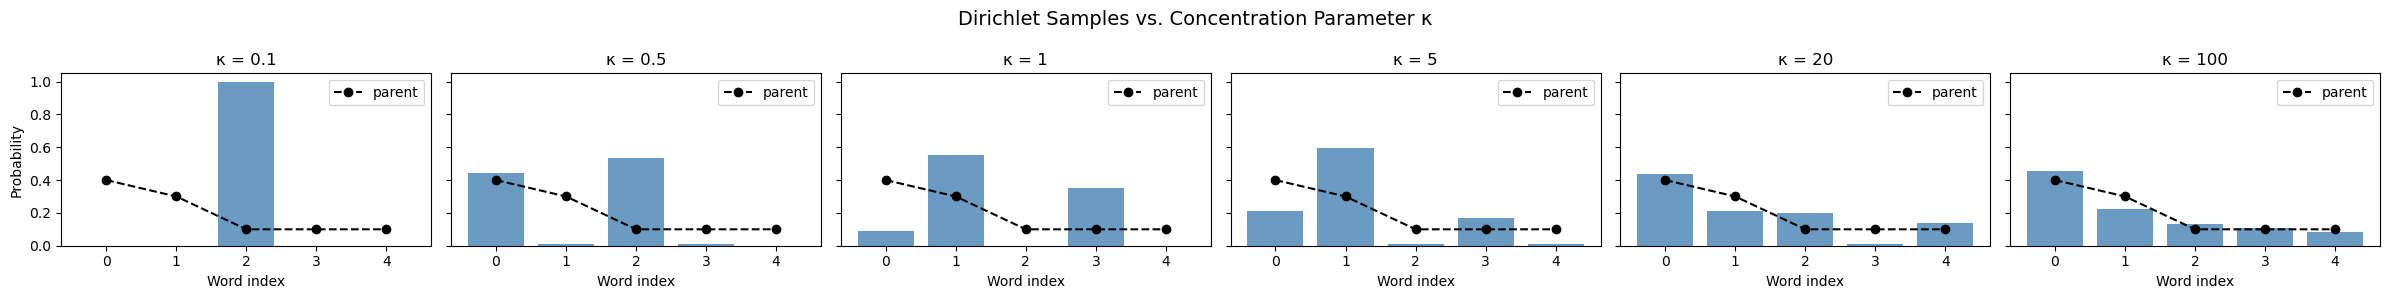

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# 1. Define parent topic (base)
# ------------------------------
theta_parent = torch.tensor([0.4, 0.3, 0.1, 0.1, 0.1])
vocab_size = len(theta_parent)

# ------------------------------
# 2. Define concentration values
# ------------------------------
kappas = [0.1, 0.5, 1, 5, 20, 100]

# ------------------------------
# 3. Sample from Dirichlet(k * theta_parent)
# ------------------------------
torch.manual_seed(0)
samples = [torch.distributions.Dirichlet(k * theta_parent).sample() for k in kappas]

# ------------------------------
# 4. Plot bar charts
# ------------------------------
fig, axes = plt.subplots(1, len(kappas), figsize=(4 * len(kappas), 3), sharey=True)

for i, (k, sample) in enumerate(zip(kappas, samples)):
    ax = axes[i]
    ax.bar(np.arange(vocab_size), sample, color='steelblue', alpha=0.8)
    ax.plot(np.arange(vocab_size), theta_parent, 'o--', color='black', label='parent')
    ax.set_title(f"κ = {k}")
    ax.set_xticks(np.arange(vocab_size))
    ax.set_xlabel("Word index")
    if i == 0:
        ax.set_ylabel("Probability")
    ax.legend()

plt.suptitle("Dirichlet Samples vs. Concentration Parameter κ", fontsize=14)
plt.tight_layout()
plt.show()


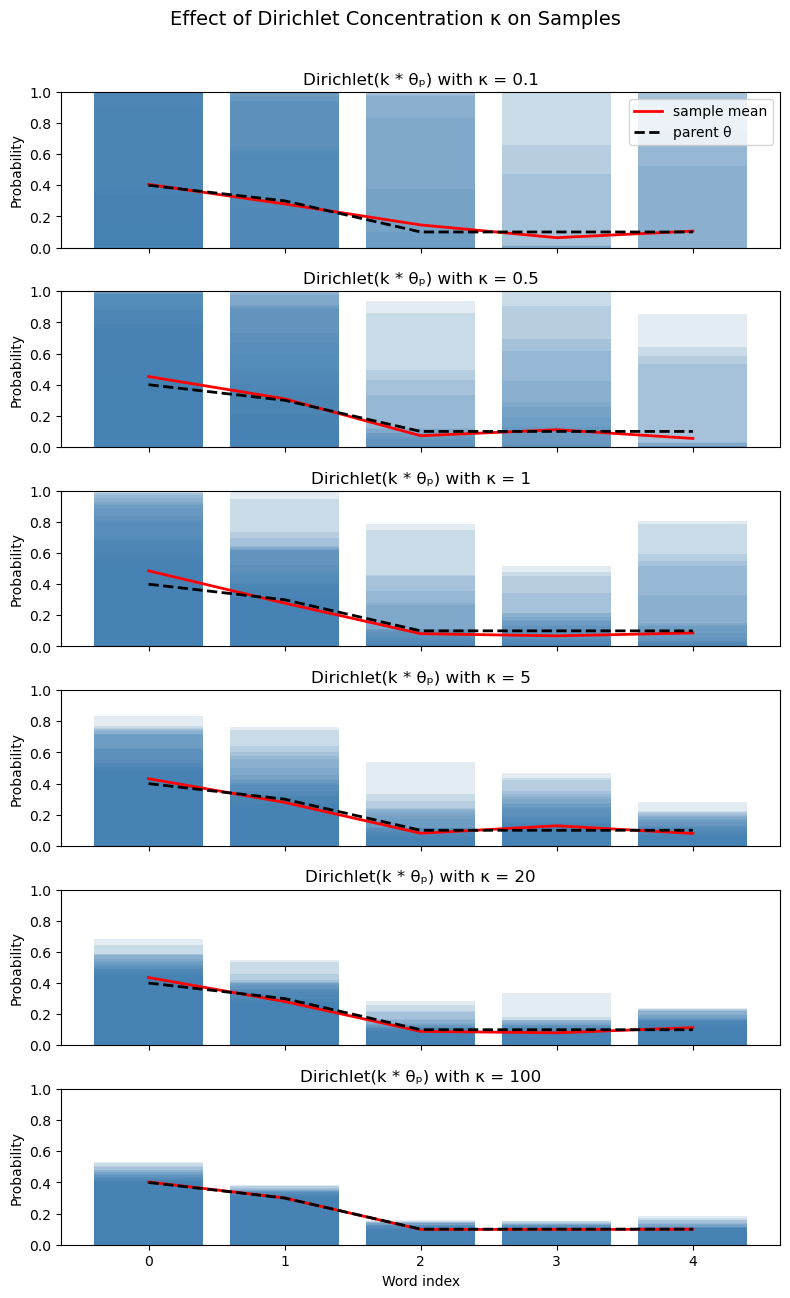

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# 1. Base parameter (parent topic)
# ------------------------------
theta_parent = torch.tensor([0.4, 0.3, 0.1, 0.1, 0.1])
vocab_size = len(theta_parent)
num_samples = 50
kappas = [0.1, 0.5, 1, 5, 20, 100]

torch.manual_seed(0)

# ------------------------------
# 2. Draw samples for each kappa
# ------------------------------
all_means = []
samples_by_k = []
for k in kappas:
    dist = torch.distributions.Dirichlet(k * theta_parent)
    samples = dist.sample((num_samples,))  # (num_samples, vocab_size)
    samples_by_k.append(samples)
    all_means.append(samples.mean(0))

# ------------------------------
# 3. Plot
# ------------------------------
fig, axes = plt.subplots(len(kappas), 1, figsize=(8, 2.2 * len(kappas)), sharex=True, sharey=True)

for i, (k, samples, sample_mean) in enumerate(zip(kappas, samples_by_k, all_means)):
    ax = axes[i]
    # Plot individual samples
    for s in samples:
        ax.bar(np.arange(vocab_size), s.numpy(), color='steelblue', alpha=0.15)
    # Plot mean of samples
    ax.plot(np.arange(vocab_size), sample_mean.numpy(), 'r-', lw=2, label='sample mean')
    # Plot parent parameter
    ax.plot(np.arange(vocab_size), theta_parent.numpy(), 'k--', lw=2, label='parent θ')
    ax.set_title(f"Dirichlet(k * θₚ) with κ = {k}")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1)
    if i == len(kappas) - 1:
        ax.set_xlabel("Word index")
    if i == 0:
        ax.legend(loc='upper right')

plt.suptitle("Effect of Dirichlet Concentration κ on Samples", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


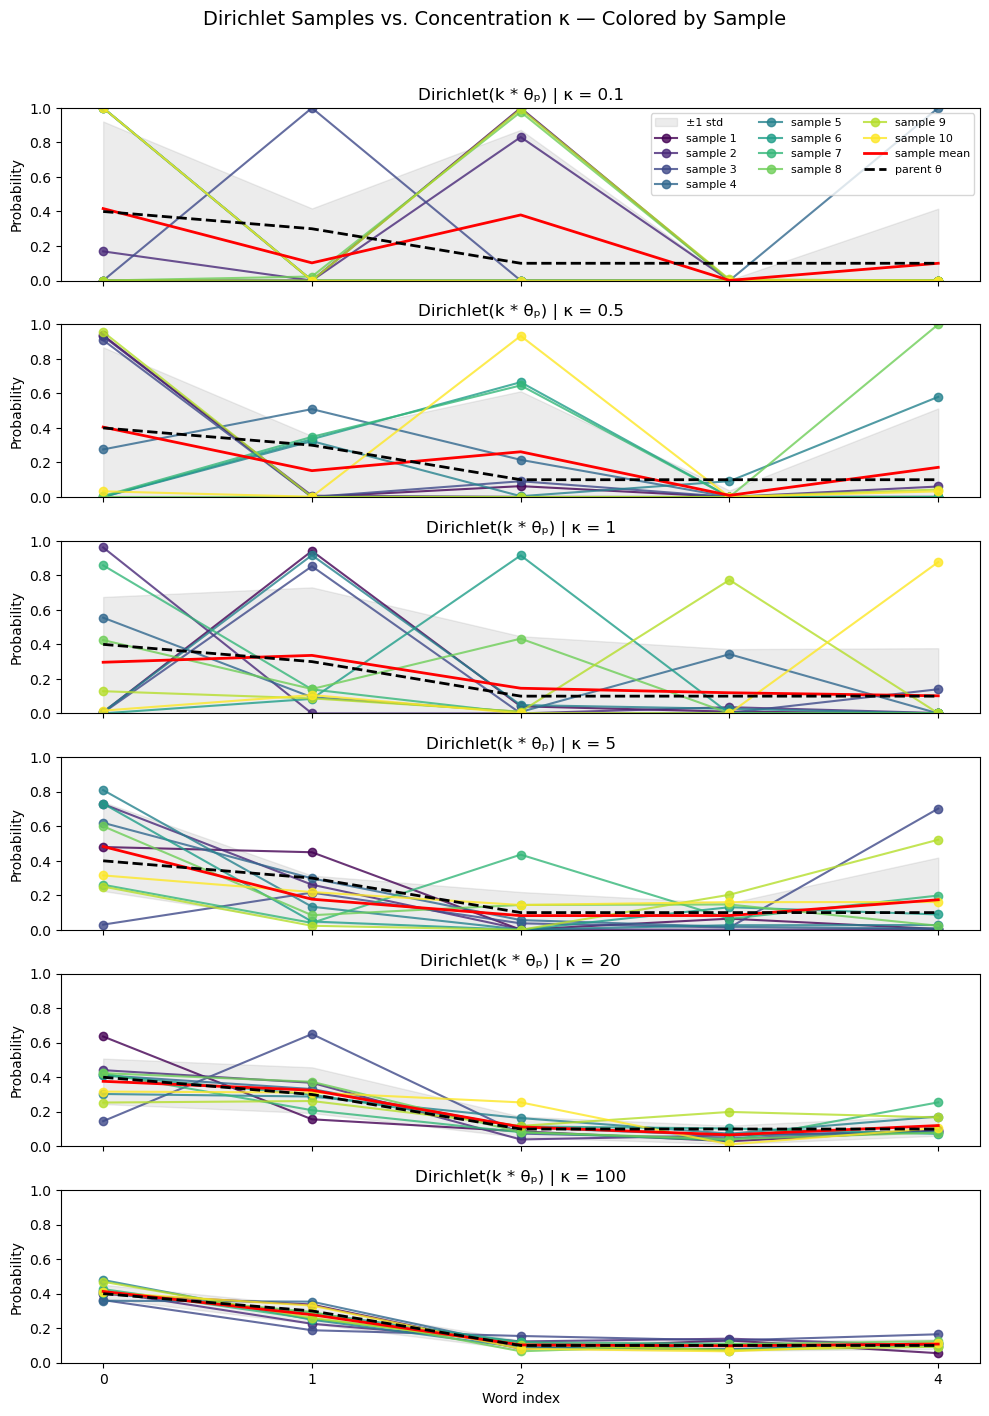

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# ------------------------------
# 1. Base Dirichlet parameter
# ------------------------------
theta_parent = torch.tensor([0.4, 0.3, 0.1, 0.1, 0.1])
vocab_size = len(theta_parent)
num_samples = 10  # smaller for clearer visualization
kappas = [0.1, 0.5, 1, 5, 20, 100]

torch.manual_seed(0)

# ------------------------------
# 2. Generate samples and compute stats
# ------------------------------
samples_by_k = []
means_by_k = []
std_by_k = []

for k in kappas:
    dist = torch.distributions.Dirichlet(k * theta_parent)
    samples = dist.sample((num_samples,))
    samples_by_k.append(samples)
    means_by_k.append(samples.mean(0))
    std_by_k.append(samples.std(0))

# ------------------------------
# 3. Visualization
# ------------------------------
fig, axes = plt.subplots(len(kappas), 1, figsize=(10, 2.4 * len(kappas)), sharex=True, sharey=True)

for i, (k, samples, mean, std) in enumerate(zip(kappas, samples_by_k, means_by_k, std_by_k)):
    ax = axes[i]
    colors = cm.viridis(np.linspace(0, 1, num_samples))
    
    # Plot variance envelope (±1 std)
    ax.fill_between(np.arange(vocab_size),
                    (mean - std).clip(min=0),
                    (mean + std).clip(max=1),
                    color='gray', alpha=0.15, label='±1 std')
    
    # Plot individual samples
    for j, s in enumerate(samples):
        ax.plot(np.arange(vocab_size), s.numpy(), marker='o', lw=1.5, alpha=0.8, color=colors[j], label=f'sample {j+1}' if i == 0 else None)
    
    # Plot mean and parent
    ax.plot(np.arange(vocab_size), mean.numpy(), 'r-', lw=2, label='sample mean' if i == 0 else None)
    ax.plot(np.arange(vocab_size), theta_parent.numpy(), 'k--', lw=2, label='parent θ' if i == 0 else None)
    
    ax.set_title(f"Dirichlet(k * θₚ) | κ = {k}")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(vocab_size))
    
axes[-1].set_xlabel("Word index")
axes[0].legend(ncol=3, loc='upper right', fontsize=8)
plt.suptitle("Dirichlet Samples vs. Concentration κ — Colored by Sample", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
